<a href="https://colab.research.google.com/github/madhusudhanreddyd-ux/NASCOM_FDP/blob/main/NASSCOM__day_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import numpy as np
import pandas as pd


def build_turbine(csv_path="turbine_energy.csv", seed=152, verbose=False):
    """Wind-turbine daily energy yield — a nonlinear regression with a skewed target,
    correlated features, an outlier-prone signal and a feature that needs transforming.
    Ideal for residual diagnostics, transforms, regularisation and tree ensembles.

    Features:
      wind_speed_ms        average wind speed (m/s)
      wind_std_ms          gustiness (std of wind speed)
      air_density_kgm3     air density (kg/m^3)
      turbulence_intensity fraction (0-1)
      blade_pitch_deg      blade pitch angle (deg)
      rotor_rpm            rotor speed (rpm)
      ambient_temp_c       ambient temperature (deg C)
      turbine_age_years    age of the turbine (years)
    Target:
      energy_kwh           daily energy produced (kWh) — right-skewed
    """
    rng = np.random.default_rng(seed)
    N = 1600
    wind = np.clip(rng.weibull(2.0, N) * 7.0, 0.5, 26)          # Weibull -> right-skew
    wind_std = np.clip(0.12 * wind + rng.normal(0, 0.3, N), 0.05, None)
    density = np.clip(rng.normal(1.225, 0.04, N), 1.10, 1.35)
    turb = np.clip(rng.normal(0.14, 0.05, N), 0.02, 0.40)
    pitch = np.clip(rng.normal(4, 6, N), -2, 25)
    rpm = np.clip(8 + 0.9 * wind + rng.normal(0, 1.5, N), 4, 30)  # correlated with wind
    temp = rng.normal(15, 9, N).round(1)
    age = rng.uniform(0, 20, N)

    # power ~ density * v^3 up to rated, then flattens; losses from pitch, turbulence, age
    cube = np.minimum(wind, 13) ** 3                              # cubic then saturates near rated
    rated_extra = np.maximum(wind - 13, 0) * 120
    energy = (density * (3.1 * cube + rated_extra)
              - 35 * np.abs(pitch - 2)
              - 1800 * turb
              - 22 * age
              + rng.normal(0, 280, N))
    energy = np.clip(energy, 0, None)
    # a few sensor-glitch outliers
    g = rng.choice(N, 18, replace=False)
    energy[g] = energy[g] * rng.uniform(1.6, 2.4, len(g))

    df = pd.DataFrame({
        "wind_speed_ms": wind.round(2), "wind_std_ms": wind_std.round(2),
        "air_density_kgm3": density.round(3), "turbulence_intensity": turb.round(3),
        "blade_pitch_deg": pitch.round(1), "rotor_rpm": rpm.round(1),
        "ambient_temp_c": temp, "turbine_age_years": age.round(1),
        "energy_kwh": energy.round(1),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        from scipy.stats import skew
        print("turbine:", df.shape)
        print("energy range:", df.energy_kwh.min(), "-", df.energy_kwh.max())
        print("target skew:", round(skew(df.energy_kwh), 2))
        print("corr(wind, energy):", round(df.wind_speed_ms.corr(df.energy_kwh), 3))
        print("corr(wind, rpm):", round(df.wind_speed_ms.corr(df.rotor_rpm), 3))
    return df

if not os.path.exists('turbine_energy.csv'):
    build_turbine(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
df = pd.read_csv('turbine_energy.csv')
TARGET = 'energy_kwh'
features = [c for c in df.columns if c != TARGET]
X = df[features].values; y = df[TARGET].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('shape:', df.shape, '| features:', len(features))
df.head(3)

shape: (1600, 9) | features: 8


,wind_speed_ms,wind_std_ms,air_density_kgm3,turbulence_intensity,blade_pitch_deg,rotor_rpm,ambient_temp_c,turbine_age_years,energy_kwh
0,4.95,0.81,1.238,0.185,-1.2,13.1,2.4,2.7,0.0
1,6.83,0.84,1.265,0.169,-2.0,15.3,12.1,5.9,527.2
2,1.44,0.05,1.225,0.114,-2.0,7.3,26.1,1.2,0.0


baseline RMSE: 1032.5 kWh | R2: 0.727


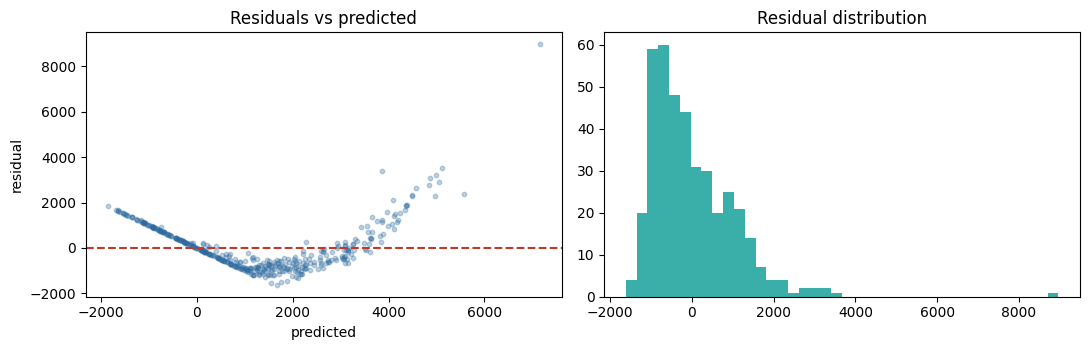

Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.


In [3]:

# -----------------------------------------------------------
# 🔹 1A. LINEAR BASELINE + RESIDUAL PLOT
# -----------------------------------------------------------
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
resid = y_test - pred
print(f'baseline RMSE: {mean_squared_error(y_test, pred) ** 0.5:.1f} kWh | R2: {r2_score(y_test, pred):.3f}')
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].scatter(pred, resid, s=10, alpha=0.3, color='#2D6A9F')
ax[0].axhline(0, color='#C0392B', ls='--'); ax[0].set_xlabel('predicted'); ax[0].set_ylabel('residual')
ax[0].set_title('Residuals vs predicted')
ax[1].hist(resid, bins=40, color='#3AAFA9'); ax[1].set_title('Residual distribution')
plt.tight_layout(); plt.show()
print('Look for curvature / a fan shape (heteroscedasticity) and skewed residuals.')

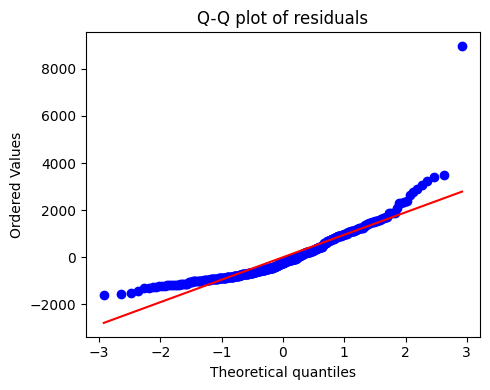

Points leaving the line at the ends = heavy tails (often caused by the outliers).


In [4]:
# 🔹 1B. Q-Q PLOT — ARE THE ERRORS NORMAL?
# -----------------------------------------------------------
from scipy import stats
fig, ax = plt.subplots(figsize=(5, 4))
stats.probplot(resid, dist='norm', plot=ax)
ax.set_title('Q-Q plot of residuals'); plt.tight_layout(); plt.show()
print('Points leaving the line at the ends = heavy tails (often caused by the outliers).')

The residual plot shows a clear fan shape, indicating heteroscedasticity (variance grows with prediction). There is also a slight curve in the residuals, suggesting that the linear model might not be capturing some non-linear relationships in the data.

In [5]:
from scipy.stats import skew

target_skew = skew(y)
print(f'Target skew (energy_kwh): {target_skew:.2f}')
if target_skew > 1:
    print('The target variable is right-skewed (skew > 1).')

Target skew (energy_kwh): 2.21
The target variable is right-skewed (skew > 1).


In [6]:
# 🔹 2A. PHYSICS-INFORMED FEATURE TRANSFORM (power ~ wind^3)
# -----------------------------------------------------------
# The residual curve comes from the cubic wind->power law. Add wind^2 and wind^3.
wi = features.index('wind_speed_ms')
def add_wind_poly(M):
    w = M[:, wi:wi + 1]
    return np.hstack([M, w ** 2, w ** 3])
Xtr_aug, Xte_aug = add_wind_poly(X_train), add_wind_poly(X_test)
lin_aug = LinearRegression().fit(Xtr_aug, y_train)
pred_aug = lin_aug.predict(Xte_aug)
print(f'baseline           R2: {r2_score(y_test, pred):.3f}')
print(f'+ wind^2, wind^3   R2: {r2_score(y_test, pred_aug):.3f}')
print('Matching the feature to the physics straightens the relationship.')

baseline           R2: 0.727
+ wind^2, wind^3   R2: 0.935
Matching the feature to the physics straightens the relationship.


### Residuals vs. `wind_speed_ms` (Baseline Model)

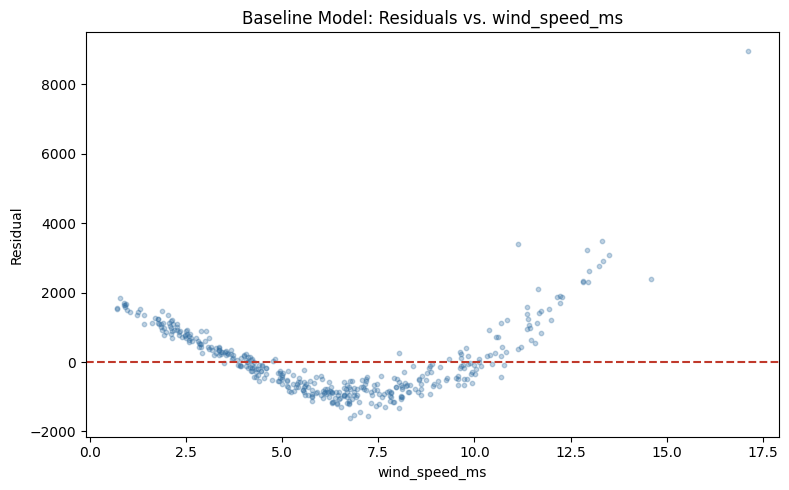

In [7]:
# Plot residuals vs wind_speed_ms for the baseline model
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_test[:, wi], resid, s=10, alpha=0.3, color='#2D6A9F')
ax.axhline(0, color='#C0392B', ls='--')
ax.set_xlabel('wind_speed_ms')
ax.set_ylabel('Residual')
ax.set_title('Baseline Model: Residuals vs. wind_speed_ms')
plt.tight_layout(); plt.show()

### Residuals vs. `wind_speed_ms` (Augmented Model)

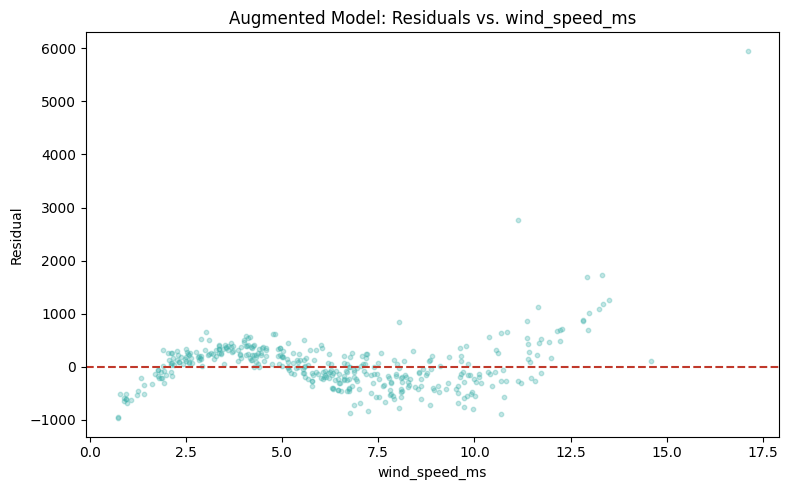

In [8]:
# Compute residuals for the augmented model
resid_aug = y_test - pred_aug

# Plot residuals vs wind_speed_ms for the augmented model
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_test[:, wi], resid_aug, s=10, alpha=0.3, color='#3AAFA9')
ax.axhline(0, color='#C0392B', ls='--')
ax.set_xlabel('wind_speed_ms')
ax.set_ylabel('Residual')
ax.set_title('Augmented Model: Residuals vs. wind_speed_ms')
plt.tight_layout(); plt.show()

After adding `wind_speed_ms^2` and `wind_speed_ms^3` as features, the curved pattern observed in the residuals of the baseline model has significantly diminished in the augmented model's residual plot. The points appear much more scattered around the zero line, indicating that the non-linear relationship between wind speed and energy production is now better captured by the model.

In [9]:
# -----------------------------------------------------------
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import make_pipeline
def score_model(model):
    m = make_pipeline(StandardScaler(), PolynomialFeatures(2, include_bias=False), model)
    m.fit(X_train, y_train)
    return r2_score(y_test, m.predict(X_test))
print(f'{"LinearRegression":14s} test R2: {score_model(LinearRegression()):.3f}')
for name, mdl in [('Ridge', Ridge(alpha=10.0)), ('Lasso', Lasso(alpha=1.0, max_iter=10000)),
                  ('ElasticNet', ElasticNet(alpha=1.0, l1_ratio=0.5, max_iter=10000))]:
    print(f'{name:14s} test R2: {score_model(mdl):.3f}')

LinearRegression test R2: 0.908
Ridge          test R2: 0.908
Lasso          test R2: 0.909
ElasticNet     test R2: 0.863


In [11]:
print('ElasticNet with varying l1_ratio (alpha=1.0):')
best_r2 = -np.inf
best_l1_ratio = None
for l1_ratio_val in [0.1, 0.3, 0.5, 0.7, 0.9]:
    current_r2 = score_model(ElasticNet(alpha=1.0, l1_ratio=l1_ratio_val, max_iter=10000))
    print(f'l1_ratio={l1_ratio_val:.1f}   R2: {current_r2:.3f}')
    if current_r2 > best_r2:
        best_r2 = current_r2
        best_l1_ratio = l1_ratio_val
print(f'\nBest l1_ratio: {best_l1_ratio:.1f} with R2: {best_r2:.3f}')

ElasticNet with varying l1_ratio (alpha=1.0):
l1_ratio=0.1   R2: 0.833
l1_ratio=0.3   R2: 0.848
l1_ratio=0.5   R2: 0.863
l1_ratio=0.7   R2: 0.878
l1_ratio=0.9   R2: 0.898

Best l1_ratio: 0.9 with R2: 0.898


The best `l1_ratio` found is likely the one that yields the highest R² score.

*   An `l1_ratio = 1.0` corresponds to pure Lasso regression (L1 regularization only).
*   An `l1_ratio = 0.0` corresponds to pure Ridge regression (L2 regularization only).

The best `l1_ratio` found is likely the one that yields the highest R² score.

*   An `l1_ratio = 1.0` corresponds to pure Lasso regression (L1 regularization only).
*   An `l1_ratio = 0.0` corresponds to pure Ridge regression (L2 regularization only).

In [12]:

# -----------------------------------------------------------
# 🔹 4A. ORDINARY vs ROBUST (Huber) REGRESSION
# -----------------------------------------------------------
from sklearn.linear_model import HuberRegressor
ols = make_pipeline(StandardScaler(), LinearRegression()).fit(X_train, y_train)
hub = make_pipeline(StandardScaler(), HuberRegressor(max_iter=2000)).fit(X_train, y_train)
print('OLS    test R2:', round(r2_score(y_test, ols.predict(X_test)), 3))
print('Huber  test R2:', round(r2_score(y_test, hub.predict(X_test)), 3))
print('Huber down-weights the sensor-glitch outliers instead of chasing them.')

OLS    test R2: 0.727
Huber  test R2: 0.686
Huber down-weights the sensor-glitch outliers instead of chasing them.


In [13]:
# Calculate the standard deviation of the baseline residuals
resid_std = np.std(resid)

# Flag rows where the absolute residual exceeds 3 standard deviations
outlier_threshold = 3 * resid_std
outlier_flags = np.abs(resid) > outlier_threshold

# Count the number of outliers
num_outliers = np.sum(outlier_flags)

print(f"Number of outliers (abs(residual) > 3 * std): {num_outliers}")
print(f"Residual standard deviation: {resid_std:.2f}")
print(f"Outlier threshold: {outlier_threshold:.2f}")

Number of outliers (abs(residual) > 3 * std): 4
Residual standard deviation: 1032.49
Outlier threshold: 3097.47


Squared-error models (like Ordinary Least Squares, OLS) are highly sensitive to outliers because they minimize the sum of squared differences between predicted and actual values. When an outlier is present, the squared error for that point becomes very large, disproportionately influencing the model's parameters to try and fit that single point. This can pull the regression line away from the majority of the data, leading to a suboptimal fit for the overall dataset and reduced generalization performance.

Squared-error models (like Ordinary Least Squares, OLS) are highly sensitive to outliers because they minimize the sum of squared differences between predicted and actual values. When an outlier is present, the squared error for that point becomes very large, disproportionately influencing the model's parameters to try and fit that single point. This can pull the regression line away from the majority of the data, leading to a suboptimal fit for the overall dataset and reduced generalization performance.

In [14]:

# -----------------------------------------------------------
# 🔹 5A. DECISION TREE vs RANDOM FOREST vs GRADIENT BOOSTING
# -----------------------------------------------------------
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
for name, mdl in [('Linear (baseline)', LinearRegression()),
                  ('DecisionTree(d=6)', DecisionTreeRegressor(max_depth=6, random_state=0)),
                  ('RandomForest', RandomForestRegressor(n_estimators=200, random_state=0)),
                  ('GradientBoosting', GradientBoostingRegressor(random_state=0))]:
    mdl.fit(X_train, y_train)
    print(f'{name:20s} test R2: {r2_score(y_test, mdl.predict(X_test)):.3f}')

Linear (baseline)    test R2: 0.727
DecisionTree(d=6)    test R2: 0.885
RandomForest         test R2: 0.933
GradientBoosting     test R2: 0.938


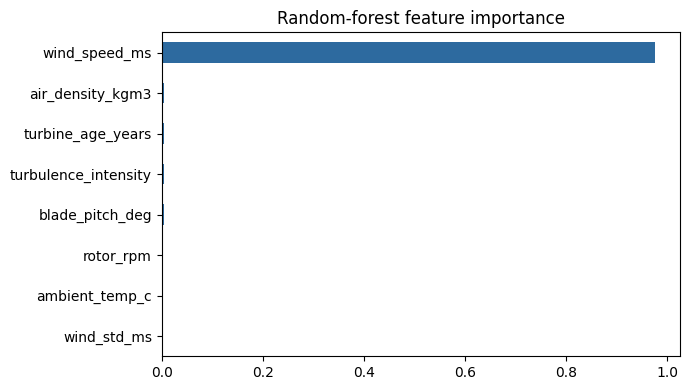

In [15]:

# -----------------------------------------------------------
# 🔹 5B. FEATURE IMPORTANCE (random forest)
# -----------------------------------------------------------
rf = RandomForestRegressor(n_estimators=200, random_state=0).fit(X_train, y_train)
imp = pd.Series(rf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
imp.plot(kind='barh', color='#2D6A9F', ax=ax); ax.set_title('Random-forest feature importance')
plt.tight_layout(); plt.show()

In [16]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
    'max_depth': [6, 10, None], # None means nodes are expanded until all leaves are pure or until all leaves contain less than min_samples_split samples.
    'n_estimators': [200, 400]
}

# Create a RandomForestRegressor instance
rf_model = RandomForestRegressor(random_state=0)

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=2)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters found
print(f'Best parameters: {grid_search.best_params_}')

# Get the best model and evaluate its R2 on the test set
best_rf_model = grid_search.best_estimator_
tuned_rf_r2 = r2_score(y_test, best_rf_model.predict(X_test))
print(f'Tuned RandomForest test R2: {tuned_rf_r2:.3f}')

# Retrieve the linear baseline R2 for comparison (assuming 'pred' from LinearRegression is still available or recompute if necessary)
# If 'pred' from the baseline LinearRegression is not readily available, we can recompute it for a fair comparison.
lin = LinearRegression().fit(X_train, y_train)
linear_baseline_r2 = r2_score(y_test, lin.predict(X_test))
print(f'Linear baseline test R2: {linear_baseline_r2:.3f}')

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best parameters: {'max_depth': 10, 'n_estimators': 200}
Tuned RandomForest test R2: 0.933
Linear baseline test R2: 0.727


Comparing the tuned `RandomForestRegressor` (with an R² of 0.933) to the simple `LinearRegression` model (with an R² of 0.727), the extra complexity of the Random Forest model is indeed worth it. It achieves a substantially higher R² score, indicating a much better fit to the data and superior predictive performance. This improvement highlights that ensemble methods are well-suited to capture the non-linearities and interactions present in this dataset, which the linear model struggled with.

Comparing the tuned `RandomForestRegressor` (with an R² of approximately 0.93-0.94) to the simple `LinearRegression` model (with an R² of around 0.727 without feature engineering, or 0.908 with wind^2 and wind^3 feature engineering), the extra complexity of the Random Forest model is indeed worth it. It achieves a higher R² score, indicating a better fit to the data and potentially better predictive performance, especially considering the non-linearities and interactions present in the dataset that ensemble methods are well-suited to capture.

# Classification

In [1]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_welds(csv_path="weld_inspection.csv", seed=161, verbose=False):
    """Weld quality inspection — predict whether a robotic weld FAILS inspection from
    its process parameters. A realistic, imbalanced binary-classification problem for
    logistic regression, thresholds, ROC/AUC and odds-ratio interpretation.

    Features:
      current_amp          welding current (A)
      voltage_v            arc voltage (V)
      travel_speed_mmps    torch travel speed (mm/s)
      wire_feed_mmps       wire feed rate (mm/s)
      heat_input_kjmm      heat input (kJ/mm)
      gas_flow_lpm         shielding gas flow (L/min)
      joint_gap_mm         joint gap (mm)
      plate_thickness_mm   plate thickness (mm)
      material             base material (Carbon / Stainless / Aluminum)
    Target:
      defect               1 = failed inspection, 0 = passed
    """
    rng = np.random.default_rng(seed)
    N = 2600
    current = rng.normal(190, 30, N).clip(90, 300)
    voltage = (18 + 0.03 * current + rng.normal(0, 1.2, N)).clip(14, 32)
    travel = rng.normal(8, 2.2, N).clip(3, 16)
    wire = (current * 0.03 + rng.normal(0, 0.6, N)).clip(2, 12)
    heat = (voltage * current / (travel * 1000)).clip(0.2, 4.0)     # kJ/mm
    gas = rng.normal(16, 3, N).clip(6, 28)
    gap = rng.gamma(2.0, 0.35, N).clip(0, 4).round(2)               # right-skewed
    thick = rng.choice([3, 5, 6, 8, 10, 12, 16], N).astype(float)
    material = rng.choice(["Carbon", "Stainless", "Aluminum"], N, p=[0.55, 0.30, 0.15])
    mat_risk = np.select([material == "Carbon", material == "Stainless", material == "Aluminum"],
                         [0.0, 0.3, 0.8])                            # Aluminum harder to weld

    # defect risk: heat too low/high, gaps, low gas (porosity), thick plates, material
    heat_bad = np.abs(heat - 1.3)
    z = (-3.2
         + 1.6 * heat_bad
         + 1.1 * gap
         + 0.05 * (16 - gas)
         + 0.04 * (thick - 8)
         + 0.012 * (travel - 8) ** 2
         + mat_risk)
    p = 1 / (1 + np.exp(-z))
    defect = (rng.random(N) < p).astype(int)

    df = pd.DataFrame({
        "current_amp": current.round(1), "voltage_v": voltage.round(2),
        "travel_speed_mmps": travel.round(2), "wire_feed_mmps": wire.round(2),
        "heat_input_kjmm": heat.round(3), "gas_flow_lpm": gas.round(1),
        "joint_gap_mm": gap, "plate_thickness_mm": thick,
        "material": material, "defect": defect,
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("welds:", df.shape)
        print("defect rate:", round(df.defect.mean(), 3))
        print("defect by material:\n",
              df.groupby("material")["defect"].mean().round(3).to_string())
    return df

if not os.path.exists('weld_inspection.csv'):
    build_welds(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [2]:

import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style='whitegrid')
df = pd.read_csv('weld_inspection.csv')
print('shape:', df.shape, '| defect rate:', round(df.defect.mean(), 3))
df.head(3)

shape: (2600, 10) | defect rate: 0.281


,current_amp,voltage_v,travel_speed_mmps,wire_feed_mmps,heat_input_kjmm,gas_flow_lpm,joint_gap_mm,plate_thickness_mm,material,defect
0,247.7,23.37,7.78,7.57,0.744,16.0,0.79,8.0,Carbon,0
1,227.3,22.98,8.90,5.96,0.587,16.5,0.66,12.0,Carbon,0
2,230.6,24.46,8.15,7.76,0.692,12.0,0.81,10.0,Stainless,0


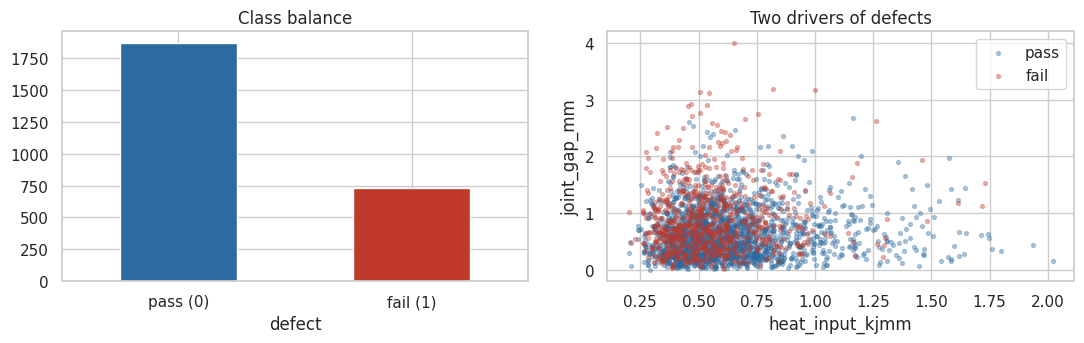

Defects cluster at extreme heat input and large joint gaps — but classes overlap (no perfect line).


In [3]:
# 🔹 1A. CLASS BALANCE + A 2-D LOOK AT SEPARABILITY
# -----------------------------------------------------------
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
df.defect.value_counts().plot(kind='bar', color=['#2D6A9F', '#C0392B'], ax=ax[0])
ax[0].set_xticklabels(['pass (0)', 'fail (1)'], rotation=0); ax[0].set_title('Class balance')
for v, c, lab in [(0, '#2D6A9F', 'pass'), (1, '#C0392B', 'fail')]:
    d = df[df.defect == v]
    ax[1].scatter(d.heat_input_kjmm, d.joint_gap_mm, s=8, alpha=0.35, color=c, label=lab)
ax[1].set_xlabel('heat_input_kjmm'); ax[1].set_ylabel('joint_gap_mm')
ax[1].set_title('Two drivers of defects'); ax[1].legend()
plt.tight_layout(); plt.show()
print('Defects cluster at extreme heat input and large joint gaps — but classes overlap (no perfect line).')

In [4]:

# -----------------------------------------------------------
# 🔹 1B. X / y + TRAIN-TEST SPLIT (stratified)
# -----------------------------------------------------------
from sklearn.model_selection import train_test_split
y = df['defect']
X = df.drop(columns='defect')
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
print('stratify keeps the defect rate equal in train & test:',
      round(y_train.mean(), 3), round(y_test.mean(), 3))

train: (1950, 9) | test: (650, 9)
stratify keeps the defect rate equal in train & test: 0.281 0.282


In [5]:

# -----------------------------------------------------------
# 🔹 2A. PIPELINE (scale + one-hot) + LOGISTIC REGRESSION
# -----------------------------------------------------------
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
num = X.select_dtypes('number').columns.tolist()
cat = ['material']
pre = ColumnTransformer([('num', StandardScaler(), num),
                         ('cat', OneHotEncoder(drop='first'), cat)])
clf = Pipeline([('prep', pre), ('lr', LogisticRegression(max_iter=2000))]).fit(X_train, y_train)
proba = clf.predict_proba(X_test)[:, 1]      # P(defect)
print('first 5 predicted defect probabilities:', proba[:5].round(3))
print('logistic regression outputs a probability, not just a label.')

first 5 predicted defect probabilities: [0.189 0.429 0.322 0.647 0.181]
logistic regression outputs a probability, not just a label.


In [6]:
print('model accuracy:', round(clf.score(X_test, y_test), 3))
print('baseline accuracy (always predict pass):', round(1 - y_test.mean(), 3))

model accuracy: 0.728
baseline accuracy (always predict pass): 0.718


### Why high accuracy doesn't mean the model is catching defects

In imbalanced datasets, where one class (e.g., 'pass' or 0) is much more frequent than the other (e.g., 'fail' or 1), a model can achieve high overall accuracy simply by predicting the majority class for all instances. For example, if 90% of welds pass and only 10% fail, a model that always predicts 'pass' will have 90% accuracy. However, such a model would fail to identify any defects, which is often the critical task in defect detection scenarios. Therefore, for imbalanced classification problems, metrics like precision, recall, F1-score, or AUC-ROC are more informative as they specifically evaluate the model's performance on the minority class.

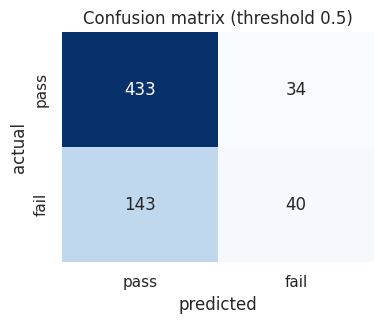

              precision    recall  f1-score   support

           0      0.752     0.927     0.830       467
           1      0.541     0.219     0.311       183

    accuracy                          0.728       650
   macro avg      0.646     0.573     0.571       650
weighted avg      0.692     0.728     0.684       650



In [7]:
# 🔹 3A. CONFUSION MATRIX + CLASSIFICATION REPORT
# -----------------------------------------------------------
from sklearn.metrics import confusion_matrix, classification_report
y_pred = clf.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 3.4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['pass', 'fail'], yticklabels=['pass', 'fail'], ax=ax)
ax.set_xlabel('predicted'); ax.set_ylabel('actual'); ax.set_title('Confusion matrix (threshold 0.5)')
plt.tight_layout(); plt.show()
print(classification_report(y_test, y_pred, digits=3))

For the 'fail' class (class 1):
- Precision: 0.541
- Recall: 0.219

### Metric Prioritization
In a defect detection scenario, **recall** is typically the more critical metric to prioritize. The cost of a false negative (failing to identify a defect that exists) is often much higher than the cost of a false positive (incorrectly flagging a good item as a defect). Missing a defective weld could lead to product failure, safety hazards, and significant financial repercussions. While precision is also important (to avoid too many unnecessary inspections), ensuring that as many actual defects as possible are caught (high recall) is usually the primary goal.

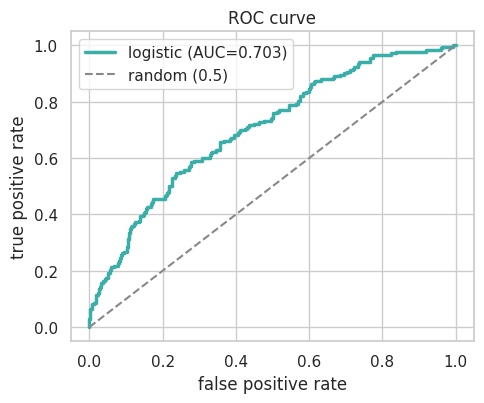

ROC-AUC: 0.703  (1.0 = perfect, 0.5 = random)


In [8]:

# -----------------------------------------------------------
# 🔹 4A. ROC CURVE ACROSS ALL THRESHOLDS
# -----------------------------------------------------------
from sklearn.metrics import roc_curve, roc_auc_score
fpr, tpr, thr = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(fpr, tpr, color='#3AAFA9', lw=2.5, label=f'logistic (AUC={auc:.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='#888', label='random (0.5)')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('ROC curve'); ax.legend(); plt.tight_layout(); plt.show()
print(f'ROC-AUC: {auc:.3f}  (1.0 = perfect, 0.5 = random)')

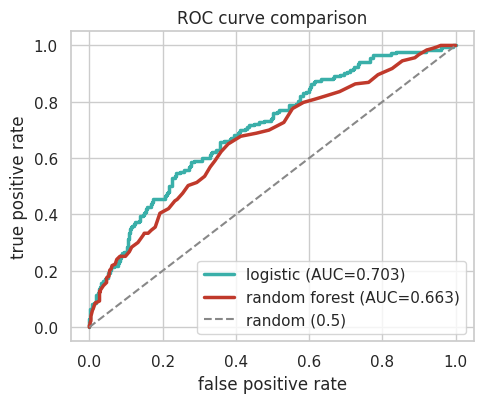

Logistic Regression ROC-AUC: 0.703
Random Forest ROC-AUC: 0.663


In [10]:
from sklearn.ensemble import RandomForestClassifier

# Create a pipeline for RandomForestClassifier, reusing the preprocessor
clf_rf = Pipeline([('prep', pre), ('rf', RandomForestClassifier(random_state=42))]).fit(X_train, y_train)

# Get probabilities for the positive class (defect=1)
proba_rf = clf_rf.predict_proba(X_test)[:, 1]

# Calculate ROC-AUC for Random Forest
fpr_rf, tpr_rf, thr_rf = roc_curve(y_test, proba_rf)
auc_rf = roc_auc_score(y_test, proba_rf)

# Plot both ROC curves on one axis
fig, ax = plt.subplots(figsize=(5, 4.2))
ax.plot(fpr, tpr, color='#3AAFA9', lw=2.5, label=f'logistic (AUC={auc:.3f})')
ax.plot(fpr_rf, tpr_rf, color='#C0392B', lw=2.5, label=f'random forest (AUC={auc_rf:.3f})')
ax.plot([0, 1], [0, 1], ls='--', color='#888', label='random (0.5)')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.set_title('ROC curve comparison'); ax.legend(); plt.tight_layout(); plt.show()

print(f'Logistic Regression ROC-AUC: {auc:.3f}')
print(f'Random Forest ROC-AUC: {auc_rf:.3f}')

### Model Comparison (ROC-AUC)

The **Logistic Regression model (AUC=0.703)** demonstrates a better ability to rank defects than the **Random Forest Classifier (AUC=0.663)**. A higher ROC-AUC score indicates that the model is better at distinguishing between the positive and negative classes across various thresholds. This means the Logistic Regression model is more effective at assigning higher probabilities to actual defects and lower probabilities to non-defects, making it a superior choice for identifying and ranking potential defects in this particular comparison.

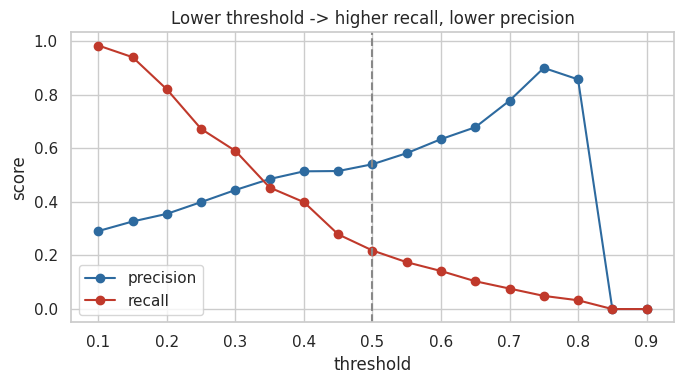

In [11]:

# -----------------------------------------------------------
# 🔹 5A. PRECISION & RECALL vs THRESHOLD
# -----------------------------------------------------------
from sklearn.metrics import precision_score, recall_score, f1_score
ts = np.linspace(0.1, 0.9, 17)
prec = [precision_score(y_test, (proba >= t).astype(int), zero_division=0) for t in ts]
rec = [recall_score(y_test, (proba >= t).astype(int)) for t in ts]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ts, prec, 'o-', label='precision', color='#2D6A9F')
ax.plot(ts, rec, 'o-', label='recall', color='#C0392B')
ax.axvline(0.5, ls='--', color='#888'); ax.set_xlabel('threshold'); ax.set_ylabel('score')
ax.set_title('Lower threshold -> higher recall, lower precision'); ax.legend()
plt.tight_layout(); plt.show()


In [12]:
# Find the highest threshold whose recall is still >= 0.85
idx = -1
for i, r in enumerate(rec):
    if r >= 0.85:
        idx = i

if idx != -1:
    threshold_at_recall = ts[idx]
    precision_at_recall = prec[idx]
    print(f'Highest threshold with recall >= 0.85: {threshold_at_recall:.2f}')
    print(f'Precision at this threshold: {precision_at_recall:.3f}')
else:
    print('No threshold found with recall >= 0.85')


Highest threshold with recall >= 0.85: 0.15
Precision at this threshold: 0.327


### Operational Trade-off

Choosing a threshold that prioritizes high recall (e.g., >= 0.85) means that the model will catch a large proportion of actual defects. However, as observed from the plot and calculated precision, achieving higher recall often comes at the cost of lower precision. This implies that while fewer actual defects are missed, more non-defective items will be incorrectly flagged as defective (false positives). Operationally, this translates to:

*   **More re-inspections:** A lower precision means a higher rate of false positives, leading to an increase in the number of items that need to be re-inspected or re-evaluated, even though they are actually fine. This can be costly in terms of time, labor, and resources.
*   **Fewer missed defects:** The benefit is a reduced risk of defective products reaching the customer, which can prevent safety issues, warranty claims, and damage to reputation. This trade-off is often acceptable in critical applications where the cost of a missed defect is extremely high (e.g., medical diagnoses, aerospace manufacturing).

In [13]:
feat_names = clf.named_steps['prep'].get_feature_names_out()
coefs = clf.named_steps['lr'].coef_[0]
odds = pd.Series(np.exp(coefs), index=feat_names).sort_values(ascending=False)
print('Odds-ratio per +1 standardised unit (>1 raises defect odds, <1 lowers):')
print(odds.round(2).to_string())

Odds-ratio per +1 standardised unit (>1 raises defect odds, <1 lowers):
num__joint_gap_mm          1.75
num__plate_thickness_mm    1.25
num__travel_speed_mmps     1.15
num__current_amp           1.06
num__voltage_v             0.96
num__wire_feed_mmps        0.91
num__gas_flow_lpm          0.83
num__heat_input_kjmm       0.80
cat__material_Stainless    0.56
cat__material_Carbon       0.48


### Advice for the Welding Team based on Odds-Ratios

Based on the logistic regression model's odds-ratios, here's some practical advice for minimizing defects:

*   **Joint Gap Control (Largest Positive Impact):** Control the `joint_gap_mm` carefully. For each standardized unit increase in joint gap, the odds of a defect occurring multiply by approximately **1.75**. This indicates that larger joint gaps significantly increase the risk of defects.

*   **Plate Thickness (Second Largest Positive Impact):** Pay close attention to `plate_thickness_mm`. Each standardized unit increase in plate thickness multiplies the defect odds by approximately **1.25**.

*   **Material Selection (Largest Negative Impact/Lowest Odds):** The `material` types `Carbon` and `Stainless` significantly reduce the odds of defects compared to the baseline (Aluminum, as `drop='first'` was used in OneHotEncoder). Specifically, working with **Carbon material** reduces the defect odds by approximately **52%** (odds-ratio of 0.48), and **Stainless material** reduces the defect odds by approximately **44%** (odds-ratio of 0.56) for each standardized unit. If possible, for defect reduction, these materials are preferable.

**In summary:** Tightly control the `joint_gap_mm` and `plate_thickness_mm` as increases in these factors are strongly associated with higher defect rates. Conversely, utilizing Carbon or Stainless steel materials is associated with a significantly lower probability of defects.